# 04 — Activations, Initialization, Saturation, and Gradient Flow

A network can have correct code and still be difficult to train. Two major causes are poor initialization and activation behavior.

### Why initialization matters

If weights are too small, signals and gradients can collapse. If they are too large, activations can saturate or explode. Good initialization tries to keep signal variance reasonably stable as it moves across layers.


In [1]:
from pathlib import Path
import urllib.request
import numpy as np
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_DIR = ROOT / 'data'
DATA_DIR.mkdir(exist_ok=True)
MNIST_PATH = DATA_DIR / 'mnist.npz'
MNIST_URL = 'https://storage.googleapis.com/tensorflow/tf-keras-datasets/mnist.npz'
if not MNIST_PATH.exists():
    print('Downloading official MNIST archive...')
    urllib.request.urlretrieve(MNIST_URL, MNIST_PATH)
with np.load(MNIST_PATH) as data:
    x_train_raw, y_train_raw = data['x_train'], data['y_train']
    x_test_raw, y_test_raw = data['x_test'], data['y_test']
print('raw train:', x_train_raw.shape, y_train_raw.shape)
print('raw test :', x_test_raw.shape, y_test_raw.shape)


def balanced_subset(x, y, per_class, seed=SEED):
    rng = np.random.default_rng(seed)
    ids = []
    for cls in range(10):
        candidates = np.flatnonzero(y == cls)
        ids.extend(rng.choice(candidates, size=per_class, replace=False))
    ids = np.array(ids)
    rng.shuffle(ids)
    return x[ids], y[ids]

x_train, y_train = balanced_subset(x_train_raw, y_train_raw, 500)
x_test, y_test = balanced_subset(x_test_raw, y_test_raw, 100)
X_train = x_train.reshape(len(x_train), -1).astype('float32') / 255.0
X_test = x_test.reshape(len(x_test), -1).astype('float32') / 255.0
print('teaching train:', X_train.shape, y_train.shape)
print('teaching test :', X_test.shape, y_test.shape)
print('pixel range   :', float(X_train.min()), 'to', float(X_train.max()))


raw train: (60000, 28, 28) (60000,)
raw test : (10000, 28, 28) (10000,)
teaching train: (5000, 784) (5000,)
teaching test : (1000, 784) (1000,)
pixel range   : 0.0 to 1.0


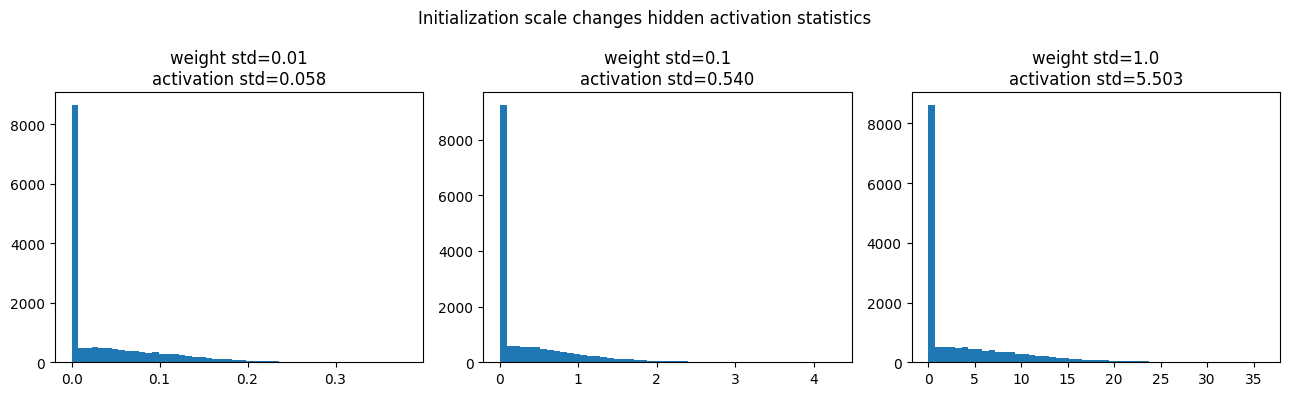

In [2]:
rng = np.random.default_rng(SEED)
X = X_train[:256]
scales = [0.01, 0.1, 1.0]
fig, axes = plt.subplots(1, 3, figsize=(13,4))
for ax, scale in zip(axes, scales):
    W = rng.normal(0, scale, size=(784,64))
    z = X @ W
    a = np.maximum(0,z)
    ax.hist(a.ravel(), bins=50)
    ax.set_title(f'weight std={scale}\nactivation std={a.std():.3f}')
plt.suptitle('Initialization scale changes hidden activation statistics')
plt.tight_layout(); plt.show()


## ReLU derivative

$$
\frac{d\,\operatorname{ReLU}(z)}{dz}=
\begin{cases}
1 & z>0\\
0 & z\le 0
\end{cases}
$$

This makes gradient flow simple but creates the possibility of "dead" units that remain on the zero side for many inputs.


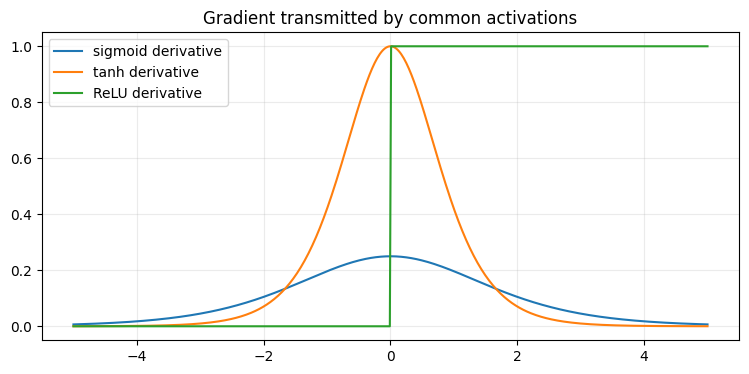

In [3]:
z = np.linspace(-5,5,500)
sig = 1/(1+np.exp(-z))
sig_grad = sig*(1-sig)
tanh_grad = 1-np.tanh(z)**2
relu_grad = (z>0).astype(float)
plt.figure(figsize=(9,4))
plt.plot(z,sig_grad,label='sigmoid derivative')
plt.plot(z,tanh_grad,label='tanh derivative')
plt.plot(z,relu_grad,label='ReLU derivative')
plt.ylim(-.05,1.05); plt.legend(); plt.grid(alpha=.25); plt.title('Gradient transmitted by common activations'); plt.show()


## Production insight

Gradient norms, activation histograms, and dead-unit rates are diagnostics. When training suddenly stalls, inspect these before blindly changing the optimizer. The failure may be representational rather than purely optimization-related.

### What to ask when training is unstable

- Are activations centered in a usable range, or are most units saturated?
- Are gradient norms close to zero, extremely large, or changing abruptly between layers?
- Does a different initialization change convergence dramatically?
- Does a smaller learning rate stabilize the same architecture?
- Are a large fraction of ReLU units permanently zero for the training population?

These questions convert a vague statement such as *the network is not learning* into measurable hypotheses. Expert ANN debugging is therefore a combination of mathematics and instrumentation.
